# STAT 248 Final Project
## Are Apple's Quarterly Returns Forecastable?

**Author:** Junle Xu

### Research question
Do Apple quarterly stock returns contain stable temporal dependence and seasonality
that are strong enough to produce out-of-sample forecasts that outperform simple naive
benchmarks on recent quarters?


## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loading import (
    load_quarterly_master, get_target, aligned_xy, chronological_split,
    merge_revenue_shares,
)
from diagnostics import (
    stationarity_summary, ljung_box, arch_test, seasonal_summary,
    acf_values, pacf_values,
)
from plotting import (
    apply_style, plot_series, plot_seasonal_box, plot_rolling_stats,
    plot_acf_pacf, plot_forecasts, plot_residual_panel, plot_metric_bars, save,
)
from models import (
    naive_historical_mean, naive_last_value, naive_seasonal,
    arima_grid_search, sarima_grid_search, fit_arima, arima_one_step_forecast,
    build_lagged_design, fit_ols, fit_ridge, fit_lasso, regression_predict,
)
from evaluation import (
    metric_table, add_relative_improvement, dm_against_baseline,
    rolling_one_step,
    make_arima_forecaster, make_sarima_forecaster,
    make_naive_mean_forecaster, make_naive_last_forecaster,
    make_naive_seasonal_forecaster, make_regression_forecaster,
)

apply_style()
OUT_TABLES = ROOT / 'outputs' / 'tables'
OUT_TABLES.mkdir(parents=True, exist_ok=True)
TEST_START = '2023Q1'
BACKTEST_START = pd.Period('2018Q1', freq='Q')


## Data

I use the Kaggle Apple Financial Dataset (1980–2026), which provides
182 quarterly observations spanning 1981Q1–2026Q2. The primary table
`aapl_quarterly_master.csv` contains the target variable `quarter_return` together
with quarterly OHLC prices, average daily return, realized volatility, and average
RSI. A secondary table `aapl_quarterly_summary.csv` carries Apple's product
revenue-share columns (Mac, Services, Wearables, iPad, iPhone), which I treat as
an optional robustness covariate from FY2009 onward (earlier quarters are missing).


In [2]:
master = load_quarterly_master()
y = get_target('quarter_return')
print(f'Observations:           {len(y)}')
print(f'Period covered:         {y.index[0]} to {y.index[-1]}')
print(f'Sample mean:            {y.mean():.4f}')
print(f'Sample std:             {y.std():.4f}')
print(f'Min / max:              {y.min():.4f} / {y.max():.4f}')
master.head(3)


Observations:           182
Period covered:         1981Q1 to 2026Q2
Sample mean:            0.0673
Sample std:             0.2362
Min / max:              -0.6557 / 0.8120


,fiscal_year,fiscal_quarter,quarter_start,quarter_end,open_price,close_price,high_price,low_price,total_volume,avg_daily_return,return_volatility,quarter_return,avg_volatility,avg_rsi,price_return_pct
period,,,,,,,,,,,,,,,
1981Q1,1981,Q1,1980-12-12,1980-12-31,0.098389,0.116784,0.123628,0.086412,1344851200,0.015527,0.049939,0.186321,NaN,NaN,0.186960
1981Q2,1981,Q2,1981-01-02,1981-03-31,0.118068,0.083845,0.118923,0.074006,1631324800,-0.004777,0.033508,-0.296170,0.006319,43.700581,-0.289856
1981Q3,1981,Q3,1981-04-01,1981-06-30,0.083417,0.088978,0.113790,0.082990,2077913600,0.001384,0.030000,0.087178,0.004790,55.890237,0.066663


## Exploratory analysis and diagnostics

I look for three things: a visible trend or regime change in the level of returns,
a seasonal pattern across fiscal quarters, and any persistent autocorrelation that an
ARIMA-style model could exploit. I also test for conditional heteroskedasticity
(volatility clustering), since it would not affect the forecastability of the *mean*
but is interesting context.


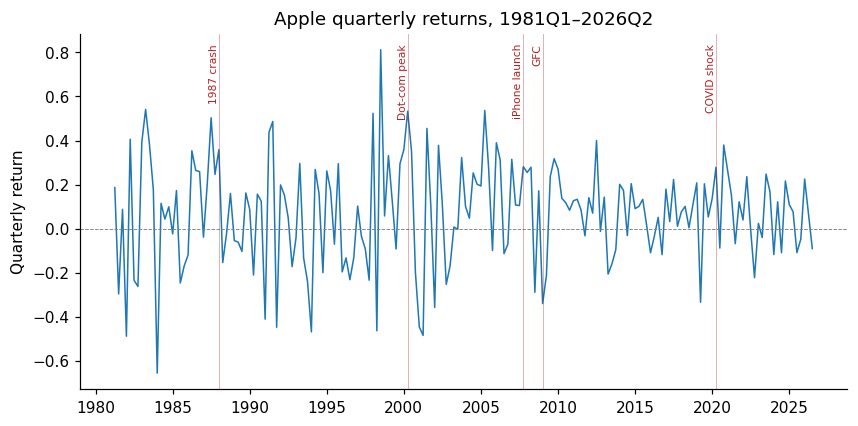

In [3]:
ax = plot_series(y, 'Apple quarterly returns, 1981Q1–2026Q2')
save(ax.figure, 'eda_series.png'); plt.show()


Returns oscillate around a small positive mean with several pronounced shocks (1987
crash, dot-com bust, 2008 GFC, 2020 COVID). There is no obvious linear trend.


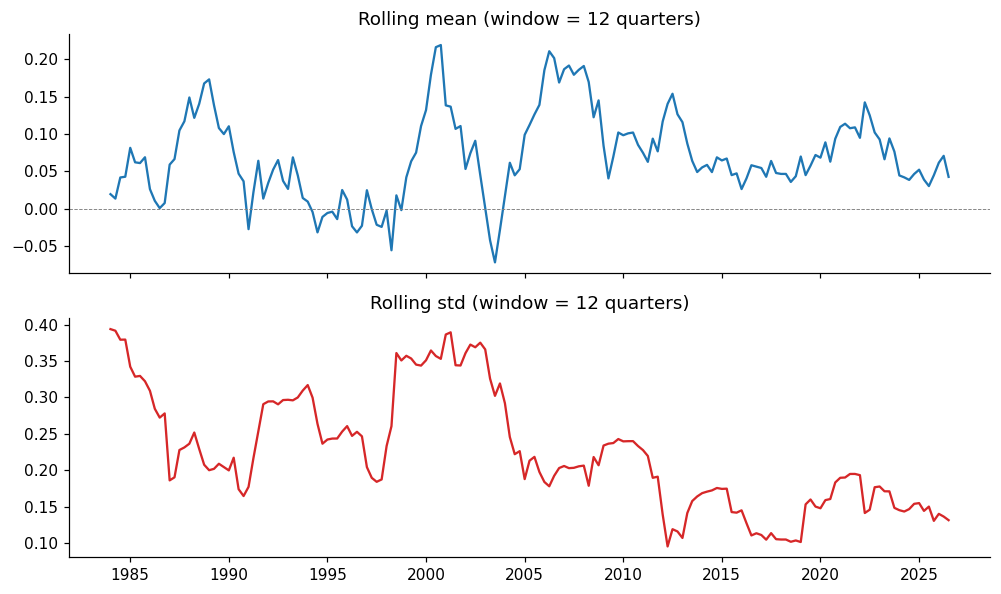

In [4]:
fig = plot_rolling_stats(y, window=12)
save(fig, 'eda_rolling.png'); plt.show()


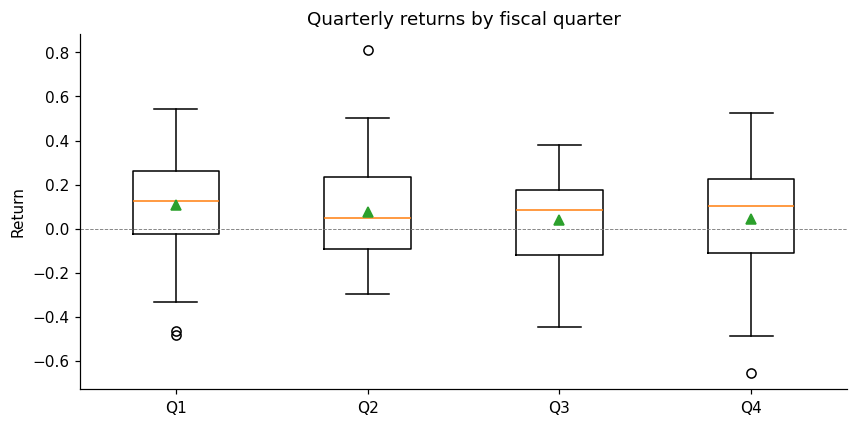

,mean,std,count
fiscal_quarter,,,
Q1,0.107568,0.236212,46
Q2,0.076487,0.237051,46
Q3,0.038076,0.197069,45
Q4,0.045920,0.270373,45


In [5]:
ax = plot_seasonal_box(y)
save(ax.figure, 'eda_seasonal_box.png'); plt.show()
seasonal_summary(y)


Seasonal means differ across quarters (Q1 > Q2 > Q4 > Q3), but within-quarter
variability is enormous (std ≈ 0.20–0.27 vs. means of 0.04–0.11), so the seasonal
signal is weak relative to noise. I will still encode quarter dummies in the
regression models and try seasonal ARIMA.


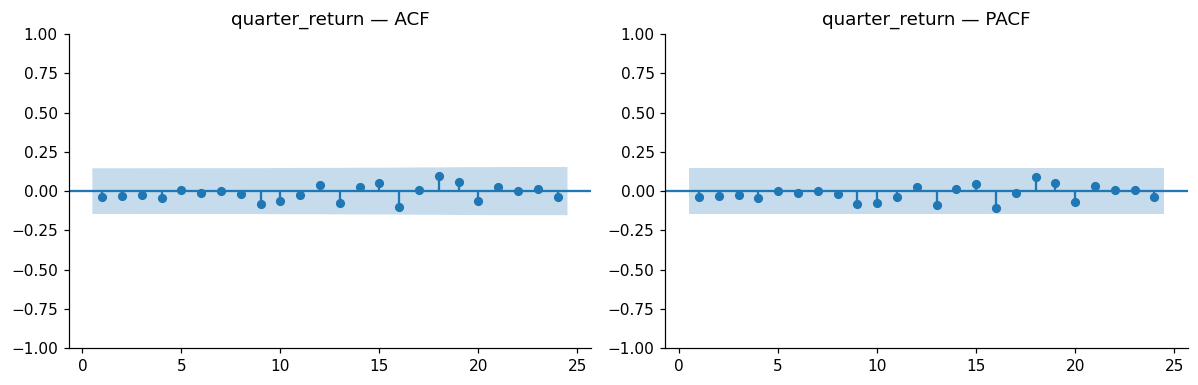

In [6]:
fig = plot_acf_pacf(y, n_lags=24, title_prefix='quarter_return — ')
save(fig, 'eda_acf_pacf.png'); plt.show()


In [7]:
stat_summary = stationarity_summary(y)
stat_summary.to_csv(OUT_TABLES / 'stationarity_tests.csv', index=False)
stat_summary


,test,statistic,p_value,lags,conclusion
0,ADF,-13.903039,5.688296e-26,0,stationary
1,KPSS,0.088048,1.000000e-01,3,stationary


Both ADF (p ≪ 0.001) and KPSS (p = 0.10) agree the series is stationary in level, so
no differencing is required for the mean. ACF and PACF show no significant spikes,
consistent with a near-white-noise mean process.


In [8]:
lb_raw = ljung_box(y, lags=(4, 8, 12, 16))
lb_raw.to_csv(OUT_TABLES / 'ljung_box_raw.csv')
lb_raw


,lb_stat,lb_pvalue,white_noise
lag,,,
4,0.884579,0.926763,True
8,0.972053,0.998419,True
12,3.332797,0.992703,True
16,7.394008,0.964899,True


In [9]:
arch_raw = arch_test(y, lags=12)
pd.DataFrame([arch_raw])


,lm_stat,lm_pvalue,f_stat,f_pvalue,homoskedastic
0,21.903172,0.038619,1.934994,0.033962,False


The mean process looks like white noise (Ljung-Box does not
reject independence at any of the lags tested), yet the ARCH test rejects
homoskedasticity (p ≈ 0.04). In other words, volatility is forecastable but the
sign and magnitude of the next return may not be — exactly the situation the
proposal anticipated. I proceed to fit mean-forecasting models anyway, because the
research question is about the predictability of the level of returns, not the
variance.


## Train/test split and backtest design

I use a strict chronological holdout starting at 2023 Q1 (14 test quarters,
168 training quarters). To check that any ranking is not an artifact of a single
test window, I also run a rolling-origin one-step backtest beginning at 2018 Q1,
which generates 34 expanding-window forecasts.


In [10]:
y_train, y_test = chronological_split(y, TEST_START)
print(f'Train: {y_train.index[0]} – {y_train.index[-1]}  (n = {len(y_train)})')
print(f'Test:  {y_test.index[0]} – {y_test.index[-1]}  (n = {len(y_test)})')


Train: 1981Q1 – 2022Q4  (n = 168)
Test:  2023Q1 – 2026Q2  (n = 14)


## Naive benchmarks

Three baselines, each requiring no fitting:
* **Historical mean** — predict every test point as the training-period mean.
* **Persistence (naive last)** — predict $\hat y_t = y_{t-1}$ using the true past value.
* **Seasonal naive** — predict $\hat y_t = y_{t-4}$ to capture year-on-year seasonality.

These are the bar that any 'real' model must clear.


In [11]:
fc = {}
fc['naive_mean']     = naive_historical_mean(y_train, y_test.index)
fc['naive_last']     = naive_last_value(y_train, y_test)
fc['naive_seasonal'] = naive_seasonal(y_train, y_test)
metric_table(y_test, fc).round(4)


,MAE,RMSE,sMAPE,MAPE_filtered,n
naive_mean,0.1152,0.1313,123.0649,85.2757,14.0
naive_last,0.1777,0.2012,151.4549,149.5633,14.0
naive_seasonal,0.1646,0.2079,126.2334,107.0151,14.0


## ARIMA and SARIMA models

I exhaustively search ARIMA orders $p,q\in\{0,1,2,3\}$ and $d\in\{0,1\}$ and pick the
AIC-minimising specification. I also fit a seasonal SARIMA grid with $s=4$ to
explicitly check whether the fiscal-quarter pattern is exploitable beyond plain ARIMA.


In [12]:
arima_table = arima_grid_search(y_train, p_range=range(0,4), d_range=range(0,2), q_range=range(0,4))
arima_table.to_csv(OUT_TABLES / 'arima_grid.csv', index=False)
arima_table.head(10)


,p,d,q,aic,bic
0,1,0,1,5.902699,18.398555
1,0,0,1,6.215626,15.587518
2,1,0,0,6.227211,15.599103
3,2,0,1,7.881088,23.500908
4,1,0,2,7.881648,23.501468
5,0,0,2,8.070015,20.565871
6,2,0,0,8.096124,20.591980
7,2,0,2,9.104336,27.848120
8,3,0,1,9.874437,28.618221
9,0,0,3,9.996782,25.616602


In [13]:
best_arima_order = (int(arima_table.iloc[0]['p']),
                    int(arima_table.iloc[0]['d']),
                    int(arima_table.iloc[0]['q']))
print('Best ARIMA order:', best_arima_order)
arima_fit = fit_arima(y_train, best_arima_order)
fc[f'ARIMA{best_arima_order}'] = arima_one_step_forecast(arima_fit, y_train, y_test)


Best ARIMA order: (1, 0, 1)


In [14]:
sarima_table = sarima_grid_search(
    y_train, p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
    P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2), s=4,
)
sarima_table.to_csv(OUT_TABLES / 'sarima_grid.csv', index=False)
sarima_table.head(10)


,p,d,q,P,D,Q,s,aic,bic
0,0,1,2,1,0,1,4,4.007629,19.383499
1,1,1,2,1,0,1,4,4.919070,23.370113
2,0,1,2,0,0,1,4,5.332099,17.632794
3,2,1,2,1,0,1,4,6.723465,28.249682
4,1,1,1,1,0,0,4,6.829494,19.179879
5,0,1,1,1,0,1,4,7.075090,19.400707
6,1,1,2,0,0,1,4,7.182624,22.558493
7,0,1,1,0,0,1,4,7.566520,16.810733
8,1,1,2,0,0,0,4,7.975558,20.375024
9,0,1,1,1,0,0,4,8.352929,17.634179


In [15]:
row = sarima_table.iloc[0]
best_sarima_order    = (int(row['p']), int(row['d']), int(row['q']))
best_sarima_seasonal = (int(row['P']), int(row['D']), int(row['Q']), int(row['s']))
print('Best SARIMA:', best_sarima_order, 'x', best_sarima_seasonal)
sarima_fit = fit_arima(y_train, best_sarima_order, seasonal_order=best_sarima_seasonal)
fc_name_sarima = f'SARIMA{best_sarima_order}x{best_sarima_seasonal}'
fc[fc_name_sarima] = arima_one_step_forecast(sarima_fit, y_train, y_test)


Best SARIMA: (0, 1, 2) x (1, 0, 1, 4)


## Lagged-regression family (OLS, Ridge, LASSO)

Design matrix: lags 1–4 of `quarter_return` plus three fiscal-quarter dummies. I
tune Ridge and LASSO penalties using `TimeSeriesSplit` with five expanding folds —
no random shuffling at any point.


In [16]:
X_full, y_aligned = build_lagged_design(y, lags=(1,2,3,4), add_quarter_dummies=True)
X_train_reg = X_full.loc[X_full.index <= y_train.index[-1]]
y_train_reg = y_aligned.loc[X_train_reg.index]
X_test_reg  = X_full.loc[y_test.index]
y_test_reg  = y_aligned.loc[X_test_reg.index]
print(f'Regression train: {X_train_reg.shape},  test: {X_test_reg.shape}')


Regression train: (164, 7),  test: (14, 7)


In [17]:
ols_fit = fit_ols(X_train_reg, y_train_reg)
ridge_fit, ridge_cv = fit_ridge(X_train_reg, y_train_reg)
lasso_fit, lasso_cv = fit_lasso(X_train_reg, y_train_reg)

fc['OLS']   = regression_predict(ols_fit,   X_test_reg)
fc['Ridge'] = regression_predict(ridge_fit, X_test_reg)
fc['LASSO'] = regression_predict(lasso_fit, X_test_reg)

coef_table = pd.DataFrame({
    'OLS': ols_fit.coefficients,
    f'Ridge (α={ridge_fit.alpha:.3g})': ridge_fit.coefficients,
    f'LASSO (α={lasso_fit.alpha:.3g})': lasso_fit.coefficients,
})
coef_table.to_csv(OUT_TABLES / 'regression_coefficients.csv')
coef_table.round(4)


,OLS,Ridge (α=1e+03),LASSO (α=0.0825)
lag1,-0.0072,-0.0010,-0.0
lag2,-0.0085,-0.0016,-0.0
lag3,-0.0039,-0.0004,-0.0
lag4,-0.0140,-0.0015,-0.0
q2,-0.0069,0.0015,0.0
q3,-0.0346,-0.0034,-0.0
q4,-0.0239,-0.0014,-0.0


Both regularised regressions push every coefficient toward zero — Ridge selects the
largest $\alpha$ in the grid, and LASSO drives all coefficients to exactly zero, recovering
the historical mean. This is consistent with the EDA: there is no useful linear
lag-and-seasonality signal that survives time-aware cross-validation.


## Evaluation: holdout, rolling backtest, and Diebold–Mariano


In [18]:
holdout_metrics = metric_table(y_test, fc)
holdout_metrics = add_relative_improvement(holdout_metrics, baseline='naive_mean', metric='RMSE')
holdout_metrics = add_relative_improvement(holdout_metrics, baseline='naive_mean', metric='MAE')
holdout_metrics.to_csv(OUT_TABLES / 'holdout_metrics.csv')
holdout_metrics.round(4)


,MAE,RMSE,sMAPE,MAPE_filtered,n,RMSE_vs_naive_mean_%,MAE_vs_naive_mean_%
naive_mean,0.1152,0.1313,123.0649,85.2757,14.0,0.0000,0.0000
naive_last,0.1777,0.2012,151.4549,149.5633,14.0,-53.2387,-54.2494
naive_seasonal,0.1646,0.2079,126.2334,107.0151,14.0,-58.3802,-42.9100
"ARIMA(1, 0, 1)",0.1157,0.1291,130.1575,86.7338,14.0,1.6968,-0.4738
"SARIMA(0, 1, 2)x(1, 0, 1, 4)",0.1121,0.1313,117.4844,86.5376,14.0,-0.0126,2.6504
OLS,0.1230,0.1406,126.9509,96.1737,14.0,-7.0846,-6.7536
Ridge,0.1159,0.1331,120.5743,86.3768,14.0,-1.3952,-0.5985
LASSO,0.1149,0.1320,120.3728,84.9946,14.0,-0.5419,0.2036


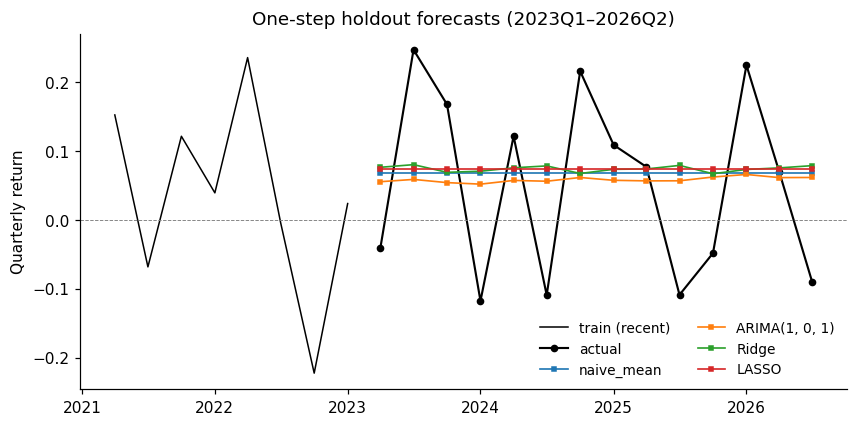

In [19]:
ax = plot_forecasts(
    y_test,
    {k: v for k, v in fc.items() if k in {'naive_mean', f'ARIMA{best_arima_order}', 'Ridge', 'LASSO'}},
    title=f'One-step holdout forecasts ({y_test.index[0]}–{y_test.index[-1]})',
    train=y_train, show_train_tail=8,
)
save(ax.figure, 'forecasts_holdout.png'); plt.show()


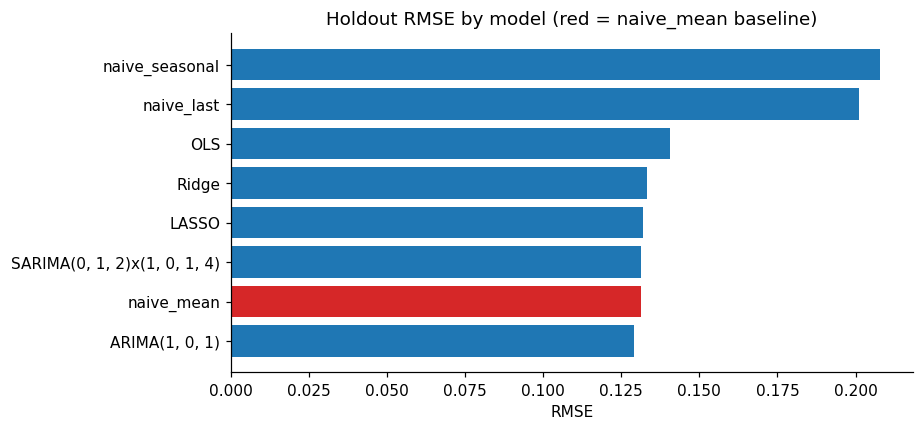

In [20]:
ax = plot_metric_bars(holdout_metrics.drop(columns=[c for c in holdout_metrics.columns if c.endswith('_%')]),
                     metric='RMSE', highlight='naive_mean',
                     title='Holdout RMSE by model (red = naive_mean baseline)')
save(ax.figure, 'holdout_rmse_bars.png'); plt.show()


In [21]:
dm_holdout = dm_against_baseline(y_test, fc, baseline='naive_mean', h=1)
dm_holdout.to_csv(OUT_TABLES / 'dm_vs_naive_mean_holdout.csv')
dm_holdout.round(4)


,dm,p_value,hln,p_hln,n
model,,,,,
naive_last,3.0870,0.0020,2.9747,0.0107,14
naive_seasonal,1.9827,0.0474,1.9106,0.0784,14
"ARIMA(1, 0, 1)",-0.7876,0.4309,-0.7589,0.4614,14
"SARIMA(0, 1, 2)x(1, 0, 1, 4)",0.0034,0.9973,0.0032,0.9975,14
OLS,1.2040,0.2286,1.1602,0.2668,14
Ridge,0.8678,0.3855,0.8362,0.4181,14
LASSO,0.5622,0.5740,0.5417,0.5972,14


Negative `dm` statistics indicate the model produces a *smaller* squared loss than
the naive-mean baseline; positive values mean it is worse. None of the model
improvements over `naive_mean` are statistically significant at conventional levels
on the 14-quarter holdout. The two persistence-style baselines (`naive_last` and
`naive_seasonal`) are *significantly worse* than the historical mean.


### Rolling-origin backtest from 2018 Q1

I re-run a one-step-ahead backtest with an expanding training window from 2018 Q1 so
every model is judged on 34 forecasts that span pre-COVID, COVID-shock, and recent
quarters. Re-fitting at every step is computationally expensive for ARIMA/SARIMA but
keeps the comparison fair.


In [22]:
roll_results = {
    'naive_mean':              rolling_one_step(y, make_naive_mean_forecaster(),     BACKTEST_START, 'naive_mean'),
    'naive_last':              rolling_one_step(y, make_naive_last_forecaster(),     BACKTEST_START, 'naive_last'),
    'naive_seasonal':          rolling_one_step(y, make_naive_seasonal_forecaster(4), BACKTEST_START, 'naive_seasonal'),
    f'ARIMA{best_arima_order}': rolling_one_step(y, make_arima_forecaster(best_arima_order), BACKTEST_START, f'ARIMA{best_arima_order}'),
    fc_name_sarima:            rolling_one_step(y, make_sarima_forecaster(best_sarima_order, best_sarima_seasonal), BACKTEST_START, fc_name_sarima),
    'Ridge':                   rolling_one_step(y, make_regression_forecaster(fit_ridge), BACKTEST_START, 'Ridge'),
    'LASSO':                   rolling_one_step(y, make_regression_forecaster(fit_lasso), BACKTEST_START, 'LASSO'),
}
roll_fc = {k: r.forecasts for k, r in roll_results.items()}
roll_actuals = next(iter(roll_results.values())).actuals
rolling_metrics_table = metric_table(roll_actuals, roll_fc)
rolling_metrics_table = add_relative_improvement(rolling_metrics_table, 'naive_mean', 'RMSE')
rolling_metrics_table = add_relative_improvement(rolling_metrics_table, 'naive_mean', 'MAE')
rolling_metrics_table.to_csv(OUT_TABLES / 'rolling_metrics.csv')
rolling_metrics_table.round(4)


,MAE,RMSE,sMAPE,MAPE_filtered,n,RMSE_vs_naive_mean_%,MAE_vs_naive_mean_%
naive_mean,0.1258,0.1545,119.2777,83.6193,34.0,0.0000,0.0000
naive_last,0.1977,0.2366,146.5007,146.5256,34.0,-53.2050,-57.1395
naive_seasonal,0.1787,0.2281,124.6530,110.2832,34.0,-47.6563,-42.0529
"ARIMA(1, 0, 1)",0.1257,0.1534,125.8256,84.4634,34.0,0.6649,0.0970
"SARIMA(0, 1, 2)x(1, 0, 1, 4)",0.1224,0.1532,113.9397,84.2647,34.0,0.8488,2.7184
Ridge,0.1267,0.1556,117.4529,84.3327,34.0,-0.7307,-0.6673
LASSO,0.1254,0.1545,116.8814,83.1855,34.0,-0.0398,0.3619


In [23]:
dm_rolling = dm_against_baseline(roll_actuals, roll_fc, baseline='naive_mean')
dm_rolling.to_csv(OUT_TABLES / 'dm_vs_naive_mean_rolling.csv')
dm_rolling.round(4)


,dm,p_value,hln,p_hln,n
model,,,,,
naive_last,3.2655,0.0011,3.2171,0.0029,34
naive_seasonal,2.5472,0.0109,2.5094,0.0172,34
"ARIMA(1, 0, 1)",-0.3764,0.7066,-0.3708,0.7131,34
"SARIMA(0, 1, 2)x(1, 0, 1, 4)",-0.4342,0.6642,-0.4277,0.6716,34
Ridge,1.0067,0.3141,0.9918,0.3285,34
LASSO,0.0721,0.9425,0.0710,0.9438,34


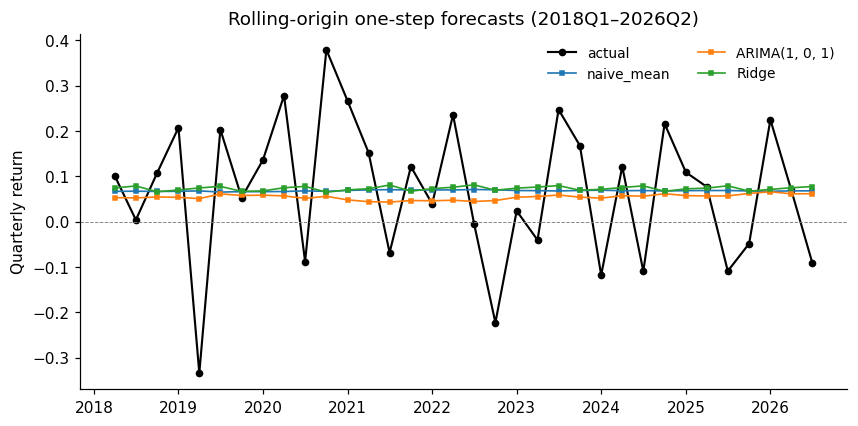

In [24]:
ax = plot_forecasts(
    roll_actuals,
    {k: v for k, v in roll_fc.items() if k in {'naive_mean', f'ARIMA{best_arima_order}', 'Ridge'}},
    title=f'Rolling-origin one-step forecasts ({roll_actuals.index[0]}–{roll_actuals.index[-1]})',
)
save(ax.figure, 'forecasts_rolling.png'); plt.show()


## Residual diagnostics on the selected ARIMA model

Because the regression family collapses to the historical mean, I run residual
diagnostics on the ARIMA model. A well-specified model should leave white-noise
residuals: zero mean, no autocorrelation, and no remaining ARCH effects.


In [25]:
arima_resid = pd.Series(arima_fit.fitted.resid, index=y_train.index, name='ARIMA residuals')
lb_resid = ljung_box(arima_resid)
lb_resid.to_csv(OUT_TABLES / 'ljung_box_residuals.csv')
arch_resid = pd.DataFrame([arch_test(arima_resid)])
arch_resid.to_csv(OUT_TABLES / 'arch_residuals.csv', index=False)
print('Ljung-Box on residuals:'); display(lb_resid)
print('ARCH test on residuals:'); display(arch_resid)


Ljung-Box on residuals:


,lb_stat,lb_pvalue,white_noise
lag,,,
4,0.108768,0.998574,True
8,0.189016,0.999997,True
12,2.100629,0.999235,True
16,5.925291,0.988883,True


ARCH test on residuals:


,lm_stat,lm_pvalue,f_stat,f_pvalue,homoskedastic
0,26.404645,0.009404,2.427983,0.006712,False


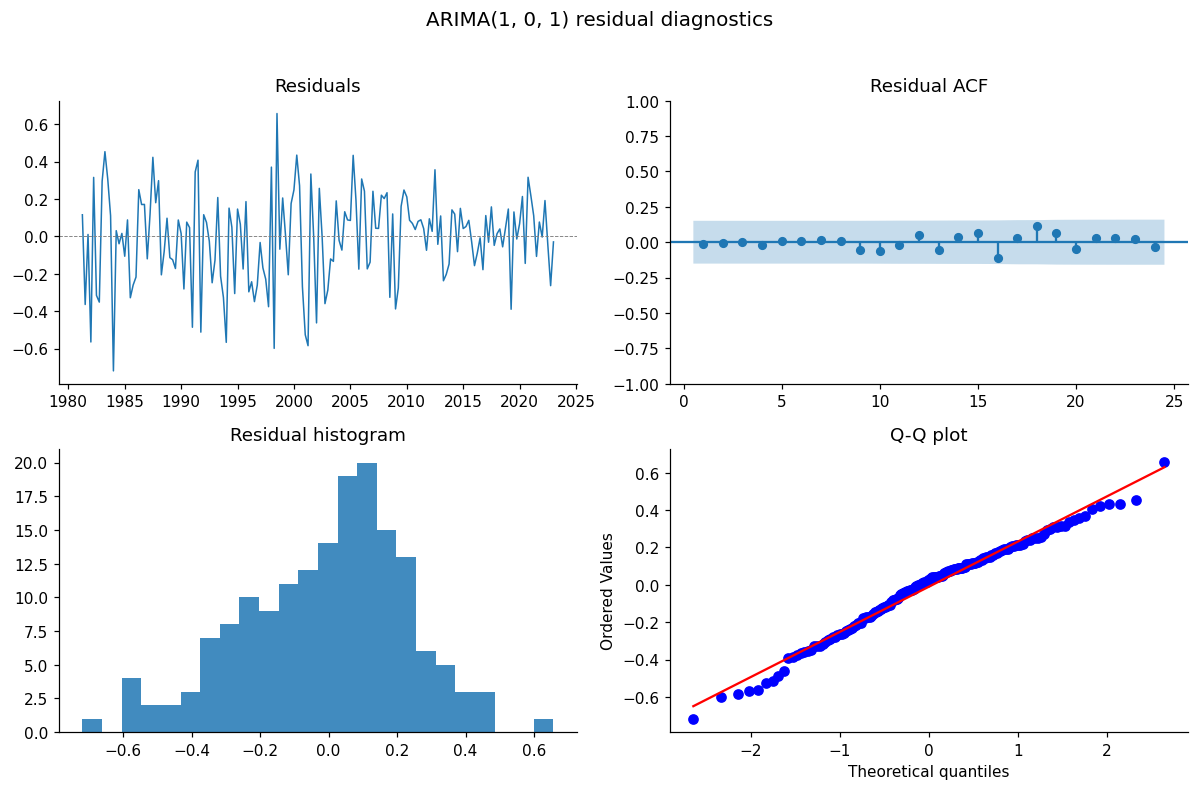

In [26]:
fig = plot_residual_panel(arima_resid, title=f'ARIMA{best_arima_order} residual diagnostics')
save(fig, 'residual_panel.png'); plt.show()


The residual ACF is well within the white-noise band and Ljung-Box does not reject
independence at any tested lag, so the ARIMA model has captured the linear
structure that exists. The ARCH test still rejects homoskedasticity, confirming that
the leftover dependence is in the variance, not the mean — a natural place for a
future GARCH analysis.


## Discussion

### Answer to the research question
Honestly no. Across both the 14-quarter holdout and the 34-quarter rolling backtest, no
candidate model produced statistically significant improvement (Diebold–Mariano) over
the historical-mean benchmark. The gap between the best ARIMA model and the naive
mean is on the order of 1–2 % of RMSE, well inside the noise band of a sample this
size. Both regularised regressions converge to the historical mean once time-aware
cross-validation is enforced, and the persistence and seasonal-naive baselines are
significantly worse than the mean.

### Why this is informative
- The diagnostics tell a coherent story: the ACF/PACF show no spikes, Ljung-Box 
does not reject white-noise, and the optimal ARIMA order has very small AR/MA 
coefficients. Quarterly returns simply look like a near-i.i.d. process around a
small positive drift.
- Volatility, however, is clustered (significant ARCH at 12 lags both on the raw
series and on residuals). So predictability lives in the second moment, not the
first — a textbook setting for GARCH/stochastic-volatility models, which is the
natural next step.

### Limitations
- Quarterly resolution gives only 168 training observations, which limits the power
of any test. A monthly or weekly study would have more statistical leverage but
raises a different research question.
- The composition of Apple's revenue has changed dramatically (iPhone went from 0 %
to roughly 50 % of revenue in the sample). The product-share covariates I left
out are only available from 2009Q1, so they cannot be used over the full sample
without sacrificing pre-2009 history.
- My test window includes a pandemic-driven structural break (2020Q1), which
dominates a few of the rolling-origin forecasts.

### Future work
- Fit a GARCH(1,1) or EGARCH on the residuals to model volatility directly and
evaluate value-at-risk forecasts.
- Replace the chronological holdout with Bayesian time-varying-parameter models that
can adapt to regime changes (state-space, Markov-switching).
- Try high-frequency predictors (analyst-estimate revisions, options implied vol)
before each earnings release to test whether information surrounding announcements
improves quarterly forecasts.
